# 90 deg 网格无关性检验

本 notebook 用于整理 `seed90_coarse.csv`、`seed90_medium.csv` 和 `seed90_fine.csv` 三个 STAR-CCM+ 监控量文件。计算口径如下：

- `C_X`、`C_Z`、`C_m` 取最后 500 次迭代的算术平均值。
- `Relative cost` 在主表中采用 cell-count proxy：以 Fine mesh 为 100%，计算 `N_g / N_F * 100%`。
- CSV 中的累计 wall-clock time 只作为内部诊断信息，不进入论文主表，避免引入硬件、并行效率和 I/O 差异。
- `Relative deviation` 按 Obsidian 文档定义，取三个系数相对 Fine mesh 的最大归一化偏差。
- 稳定性诊断只作为审阅依据，不放入论文主表，避免主表变成解释性清单。


## 1. 基础配置与工具函数

这一单元只定义路径、网格信息、列名映射和几个轻量工具函数。为了便于在不同工作目录下运行，数据目录会从多个相对位置自动查找。

In [1]:
from pathlib import Path
import csv
import math
from statistics import mean, stdev

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = None

LAST_N = 500
MESH_ORDER = ["Coarse", "Medium", "Fine"]
MESH_CONFIG = {
    "Coarse": {"file": "seed90_coarse.csv", "cells_million": 5.51},
    "Medium": {"file": "seed90_medium.csv", "cells_million": 8.22},
    "Fine": {"file": "seed90_fine.csv", "cells_million": 12.43},
}
COEFF_COLUMNS = {
    "Cx": "Cx Monitor",
    "Cz": "Cz Monitor",
    "Cm": "Cm Monitor",
}


def show_markdown(text):
    """在 notebook 中渲染 Markdown；在普通 Python 中退化为 print。"""
    if Markdown is not None and display is not None:
        display(Markdown(text))
    else:
        print(text)


def find_data_dir():
    cwd = Path.cwd()
    candidates = [
        cwd / "data",
        cwd.parent / "data",
        cwd / "网格无关性" / "data",
        cwd.parent / "网格无关性" / "data",
    ]
    for candidate in candidates:
        if all((candidate / cfg["file"]).exists() for cfg in MESH_CONFIG.values()):
            return candidate
    raise FileNotFoundError("未找到 seed90_coarse/medium/fine.csv 所在的 data 目录。")


def markdown_table(headers, rows, align=None):
    align = align or [":---"] * len(headers)
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(align) + " |",
    ]
    for row in rows:
        lines.append("| " + " | ".join(str(item) for item in row) + " |")
    return "\n".join(lines)


DATA_DIR = find_data_dir()
print(f"数据目录: {DATA_DIR}")

数据目录: C:\AD_v2_stage1_analysis\网格无关性\data


## 2. 读取三套网格监控量

这一单元读取三份 CSV，统一字段名，并检查每个算例是否至少包含 500 次迭代。运行时间列采用导出文件中以 `Monitor (s)` 结尾的列。

In [2]:
def read_monitor_csv(path):
    with path.open(newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        rows_raw = list(reader)

    if not rows_raw:
        raise ValueError(f"CSV 为空: {path}")

    time_col = next((col for col in rows_raw[0] if "Monitor (s)" in col), None)
    if time_col is None:
        raise ValueError(f"未找到运行时间列: {path}")

    rows = []
    for raw in rows_raw:
        rows.append({
            "Iteration": int(float(raw["Iteration"])),
            "Cx": float(raw[COEFF_COLUMNS["Cx"]]),
            "Cz": float(raw[COEFF_COLUMNS["Cz"]]),
            "Cm": float(raw[COEFF_COLUMNS["Cm"]]),
            "time_s": float(raw[time_col]) if raw.get(time_col, "").strip() else math.nan,
        })

    if len(rows) < LAST_N:
        raise ValueError(f"{path.name} 只有 {len(rows)} 行，不足最后 {LAST_N} 次迭代平均。")

    return rows, time_col


runs = {}
load_rows = []
time_column_name = None

for mesh in MESH_ORDER:
    path = DATA_DIR / MESH_CONFIG[mesh]["file"]
    rows, time_col = read_monitor_csv(path)
    runs[mesh] = rows
    time_column_name = time_column_name or time_col
    load_rows.append([
        mesh,
        path.name,
        f"{rows[0]['Iteration']}--{rows[-1]['Iteration']}",
        f"{len(rows)}",
        f"{rows[-1]['time_s']:.1f}",
    ])

show_markdown(markdown_table(
    ["Mesh", "CSV", "Iteration range", "Rows", "Final wall time (s)"],
    load_rows,
    [":---", ":---", "---:", "---:", "---:"],
))

| Mesh | CSV | Iteration range | Rows | Final wall time (s) |
| :--- | :--- | ---: | ---: | ---: |
| Coarse | seed90_coarse.csv | 1--3500 | 3500 | 15738.1 |
| Medium | seed90_medium.csv | 1--3500 | 3500 | 22646.5 |
| Fine | seed90_fine.csv | 1--3500 | 3500 | 76977.9 |

## 3. 最后 500 次迭代均值

这一单元只负责计算最终进入论文主表的三个系数。使用最后 500 次迭代平均，而不是最后一个迭代点，可以降低强分离工况下残余振荡对单点结果的影响。

In [3]:
last500_windows = {mesh: rows[-LAST_N:] for mesh, rows in runs.items()}
last500_means = {}

for mesh, window in last500_windows.items():
    last500_means[mesh] = {
        coeff: mean(row[coeff] for row in window)
        for coeff in ["Cx", "Cz", "Cm"]
    }

mean_rows = []
for mesh in MESH_ORDER:
    values = last500_means[mesh]
    mean_rows.append([
        mesh,
        f"{values['Cx']:.6f}",
        f"{values['Cz']:.6f}",
        f"{values['Cm']:.6f}",
    ])

show_markdown(markdown_table(
    ["Mesh", "last500 $C_X$", "last500 $C_Z$", "last500 $C_m$"],
    mean_rows,
    [":---", "---:", "---:", "---:"],
))

| Mesh | last500 $C_X$ | last500 $C_Z$ | last500 $C_m$ |
| :--- | ---: | ---: | ---: |
| Coarse | 0.909770 | -5.380709 | 0.359700 |
| Medium | 0.434795 | -5.053645 | 0.208104 |
| Fine | 0.523456 | -5.099415 | 0.210893 |

## 4. 论文主表：cell-count proxy 与相对偏差

主表中的 `Relative cost` 改用 cell-count proxy，而不是 wall-clock time：

$$
\mathrm{Cost}_{rel}^{g} = \frac{N_g}{N_F}\times 100\% .
$$

其中 $N_g$ 是当前网格单元数，$N_F$ 是 Fine mesh 单元数。这样更适合论文主表，因为它可复现、与网格规模直接相关，并且不会把硬件状态、并行效率、I/O 或求解器非线性开销带入网格无关性结论。

`Relative deviation` 仍然使用 Fine mesh 三个系数绝对值中的最大量纲作为归一化尺度：

$$
\mathrm{Dev}_{rel}^{g} =
\frac{\max(|C_X^g-C_X^F|, |C_Z^g-C_Z^F|, |C_m^g-C_m^F|)}
{\max(|C_X^F|, |C_Z^F|, |C_m^F|)}\times 100\% .
$$


In [4]:
fine_means = last500_means["Fine"]
fine_norm = max(abs(fine_means[coeff]) for coeff in ["Cx", "Cz", "Cm"])
fine_cells = MESH_CONFIG["Fine"]["cells_million"]

final_table = []
for mesh in MESH_ORDER:
    values = last500_means[mesh]
    rel_cost = MESH_CONFIG[mesh]["cells_million"] / fine_cells * 100.0
    max_abs_deviation = max(abs(values[coeff] - fine_means[coeff]) for coeff in ["Cx", "Cz", "Cm"])
    rel_deviation = max_abs_deviation / fine_norm * 100.0
    final_table.append({
        "Mesh": mesh,
        "Cells": f"{MESH_CONFIG[mesh]['cells_million']:.2f} million",
        "C_X": values["Cx"],
        "C_Z": values["Cz"],
        "C_m": values["Cm"],
        "Relative cost": rel_cost,
        "Relative deviation": rel_deviation,
    })

final_rows = [[
    row["Mesh"],
    row["Cells"],
    f"{row['C_X']:.4f}",
    f"{row['C_Z']:.4f}",
    f"{row['C_m']:.4f}",
    f"{row['Relative cost']:.1f}%",
    f"{row['Relative deviation']:.2f}%",
] for row in final_table]

final_table_markdown = markdown_table(
    ["Mesh", "Cells", "$C_X$", "$C_Z$", "$C_m$", "Relative cost", "Relative deviation"],
    final_rows,
    [":---", "---:", "---:", "---:", "---:", "---:", "---:"],
)
show_markdown(final_table_markdown)


| Mesh | Cells | $C_X$ | $C_Z$ | $C_m$ | Relative cost | Relative deviation |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| Coarse | 5.51 million | 0.9098 | -5.3807 | 0.3597 | 44.3% | 7.58% |
| Medium | 8.22 million | 0.4348 | -5.0536 | 0.2081 | 66.1% | 1.74% |
| Fine | 12.43 million | 0.5235 | -5.0994 | 0.2109 | 100.0% | 0.00% |

## 5. 分量偏差诊断

论文主表使用最大归一化偏差，避免某个较小系数接近零时造成百分比误差失真。为了内部审阅，这里额外列出每个系数相对 Fine mesh 的绝对差值和分量相对差值。该诊断不建议直接放入主表。

In [5]:
component_rows = []
for mesh in MESH_ORDER:
    for coeff in ["Cx", "Cz", "Cm"]:
        value = last500_means[mesh][coeff]
        fine_value = fine_means[coeff]
        abs_diff = abs(value - fine_value)
        component_rel = abs_diff / abs(fine_value) * 100.0 if abs(fine_value) > 1e-12 else math.nan
        norm_rel = abs_diff / fine_norm * 100.0
        component_rows.append([
            mesh,
            coeff,
            f"{value:.6f}",
            f"{abs_diff:.6f}",
            f"{component_rel:.2f}%",
            f"{norm_rel:.2f}%",
        ])

show_markdown(markdown_table(
    ["Mesh", "Coeff.", "Mean", "Abs. diff. vs Fine", "Component rel. diff.", "Fine-norm diff."],
    component_rows,
    [":---", ":---", "---:", "---:", "---:", "---:"],
))

| Mesh | Coeff. | Mean | Abs. diff. vs Fine | Component rel. diff. | Fine-norm diff. |
| :--- | :--- | ---: | ---: | ---: | ---: |
| Coarse | Cx | 0.909770 | 0.386314 | 73.80% | 7.58% |
| Coarse | Cz | -5.380709 | 0.281294 | 5.52% | 5.52% |
| Coarse | Cm | 0.359700 | 0.148807 | 70.56% | 2.92% |
| Medium | Cx | 0.434795 | 0.088661 | 16.94% | 1.74% |
| Medium | Cz | -5.053645 | 0.045770 | 0.90% | 0.90% |
| Medium | Cm | 0.208104 | 0.002790 | 1.32% | 0.05% |
| Fine | Cx | 0.523456 | 0.000000 | 0.00% | 0.00% |
| Fine | Cz | -5.099415 | 0.000000 | 0.00% | 0.00% |
| Fine | Cm | 0.210893 | 0.000000 | 0.00% | 0.00% |

## 6. 最后 500 次迭代稳定性诊断

这一单元评价最后 500 次迭代是否适合作为平均窗口。关注四个指标：标准差、极差、前 250 步与后 250 步均值差、线性趋势幅值。`C_m` 数值较小，百分比指标会偏敏感，因此需要同时看绝对波动。

In [6]:
def linear_trend_delta(values):
    n = len(values)
    x_bar = (n - 1) / 2.0
    y_bar = mean(values)
    denominator = sum((i - x_bar) ** 2 for i in range(n))
    slope = sum((i - x_bar) * (value - y_bar) for i, value in enumerate(values)) / denominator
    return slope * (n - 1)


stability_stats = {}
stability_rows = []

for mesh in MESH_ORDER:
    stability_stats[mesh] = {}
    for coeff in ["Cx", "Cz", "Cm"]:
        values = [row[coeff] for row in last500_windows[mesh]]
        avg = mean(values)
        denom = abs(avg) if abs(avg) > 1e-12 else 1.0
        std_value = stdev(values)
        range_value = max(values) - min(values)
        first_half = mean(values[: LAST_N // 2])
        second_half = mean(values[LAST_N // 2 :])
        trend_delta = linear_trend_delta(values)
        stats = {
            "mean": avg,
            "std": std_value,
            "cv_pct": std_value / denom * 100.0,
            "range": range_value,
            "range_pct": range_value / denom * 100.0,
            "half_drift": second_half - first_half,
            "half_drift_pct": abs(second_half - first_half) / denom * 100.0,
            "trend_delta": trend_delta,
            "trend_pct": abs(trend_delta) / denom * 100.0,
        }
        stability_stats[mesh][coeff] = stats
        stability_rows.append([
            mesh,
            coeff,
            f"{stats['std']:.6f}",
            f"{stats['cv_pct']:.2f}%",
            f"{stats['range']:.6f}",
            f"{stats['range_pct']:.2f}%",
            f"{stats['half_drift']:.6f}",
            f"{stats['half_drift_pct']:.2f}%",
            f"{stats['trend_delta']:.6f}",
            f"{stats['trend_pct']:.2f}%",
        ])

show_markdown(markdown_table(
    ["Mesh", "Coeff.", "Std.", "CV", "Range", "Range/mean", "Half-window drift", "Drift/mean", "Linear trend", "Trend/mean"],
    stability_rows,
    [":---", ":---", "---:", "---:", "---:", "---:", "---:", "---:", "---:", "---:"],
))

| Mesh | Coeff. | Std. | CV | Range | Range/mean | Half-window drift | Drift/mean | Linear trend | Trend/mean |
| :--- | :--- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Coarse | Cx | 0.016155 | 1.78% | 0.065920 | 7.25% | 0.001998 | 0.22% | 0.009564 | 1.05% |
| Coarse | Cz | 0.015417 | 0.29% | 0.069469 | 1.29% | -0.001782 | 0.03% | -0.016835 | 0.31% |
| Coarse | Cm | 0.006709 | 1.87% | 0.028069 | 7.80% | 0.002063 | 0.57% | 0.008419 | 2.34% |
| Medium | Cx | 0.017426 | 4.01% | 0.081554 | 18.76% | 0.020354 | 4.68% | 0.033822 | 7.78% |
| Medium | Cz | 0.032848 | 0.65% | 0.143352 | 2.84% | 0.015625 | 0.31% | 0.022100 | 0.44% |
| Medium | Cm | 0.013896 | 6.68% | 0.054243 | 26.07% | -0.006414 | 3.08% | -0.003975 | 1.91% |
| Fine | Cx | 0.014423 | 2.76% | 0.071956 | 13.75% | -0.004019 | 0.77% | -0.012504 | 2.39% |
| Fine | Cz | 0.042978 | 0.84% | 0.153919 | 3.02% | -0.008007 | 0.16% | -0.026512 | 0.52% |
| Fine | Cm | 0.015960 | 7.57% | 0.063762 | 30.23% | -0.004732 | 2.24% | -0.007015 | 3.33% |

## 7. 最后 500 次迭代曲线

这一单元绘制最后 500 次迭代的三个系数曲线，用于快速检查是否存在持续漂移、突跳或明显周期振荡。若当前环境没有 `matplotlib`，可跳过该图，不影响前面的表格计算。

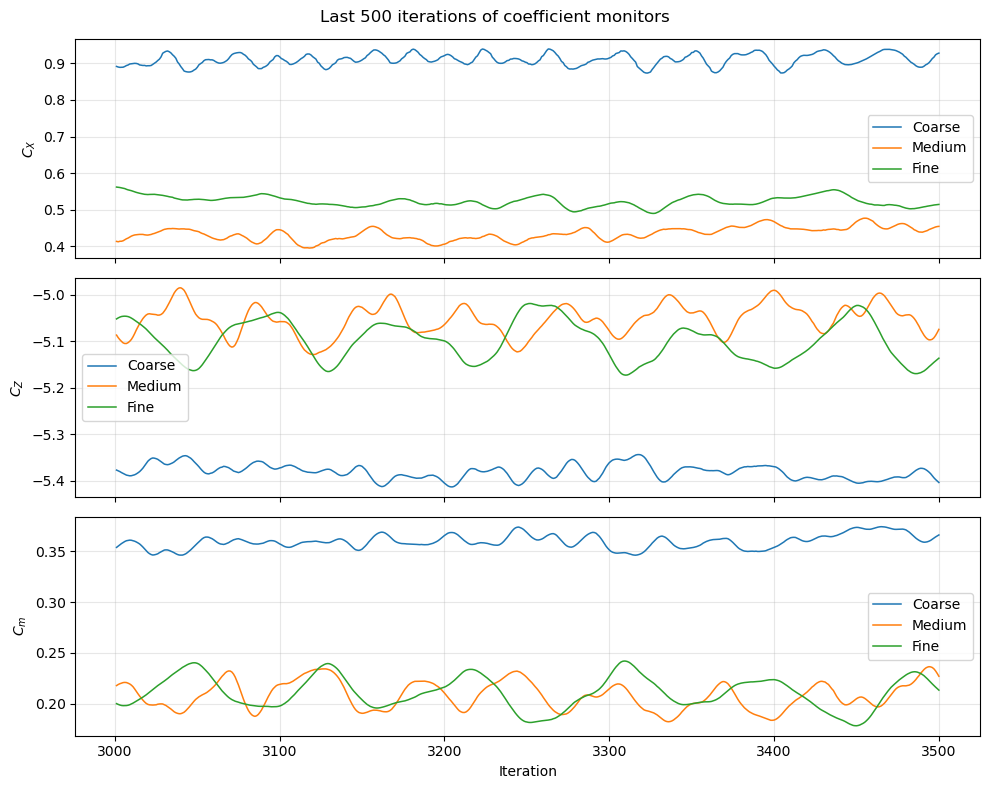

In [7]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for ax, coeff, label in zip(axes, ["Cx", "Cz", "Cm"], ["$C_X$", "$C_Z$", "$C_m$"]):
        for mesh in MESH_ORDER:
            iterations = [row["Iteration"] for row in last500_windows[mesh]]
            values = [row[coeff] for row in last500_windows[mesh]]
            ax.plot(iterations, values, label=mesh, linewidth=1.1)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
    axes[-1].set_xlabel("Iteration")
    fig.suptitle("Last 500 iterations of coefficient monitors")
    fig.tight_layout()
    in_kernel = "get_ipython" in globals() and getattr(get_ipython(), "kernel", None) is not None
    if in_kernel:
        plt.show()
    else:
        print("曲线图已生成；当前为非 notebook 环境，命令行验证时自动关闭图窗。")
        plt.close(fig)
except ImportError:
    print("当前环境未安装 matplotlib，已跳过曲线绘制。")

## 8. 结论文本生成

这一单元根据上面的表格自动生成一段中文审阅结论。正式论文写作时，应把结论边界控制在“代表性高风险攻角下的网格无关性检验”，不要扩展成全攻角、全瞬态或完整释放过程验证。

In [8]:
medium = next(row for row in final_table if row["Mesh"] == "Medium")
coarse = next(row for row in final_table if row["Mesh"] == "Coarse")
fine = next(row for row in final_table if row["Mesh"] == "Fine")

max_medium_trend = max(stability_stats["Medium"][coeff]["trend_pct"] for coeff in ["Cx", "Cz", "Cm"])
max_medium_drift = max(stability_stats["Medium"][coeff]["half_drift_pct"] for coeff in ["Cx", "Cz", "Cm"])

conclusion = f"""
### 网格无关性检验结论

1. 在 $90^\circ$ 代表性高载荷分离工况下，Coarse、Medium、Fine 三套网格最后 {LAST_N} 次迭代均值分别给出了稳定的 $C_Z$ 主导载荷水平。按 Fine mesh 归一化的最大系数偏差，Coarse 为 {coarse['Relative deviation']:.2f}%，Medium 为 {medium['Relative deviation']:.2f}%，Fine 为 {fine['Relative deviation']:.2f}%。
2. 主表中的 Relative cost 采用 cell-count proxy。Medium mesh 的相对网格规模为 Fine mesh 的 {medium['Relative cost']:.1f}%，但相对偏差只有 {medium['Relative deviation']:.2f}%；Coarse mesh 的相对网格规模为 Fine mesh 的 {coarse['Relative cost']:.1f}%，但偏差升至 {coarse['Relative deviation']:.2f}%。因此，Medium mesh 在网格规模和系数一致性之间更适合作为后续 full AoA sweep 的 production mesh。
3. CSV 中 wall-clock time 仅作为内部诊断，不建议进入论文主表。最后 {LAST_N} 次迭代平均作为最终结果是合适的，但需要克制表述。$C_Z$ 的波动和漂移很小；$C_X$ 与 $C_m$ 在强分离工况下仍存在低幅残余漂移或振荡，其中 Medium mesh 最大半窗漂移约 {max_medium_drift:.2f}%，最大线性趋势约 {max_medium_trend:.2f}%。因此，应使用最后 {LAST_N} 次平均而不是末次迭代值作为表格结果，并在论文中表述为 model-level quasi-static closure 的网格检验，不应声称所有攻角或完整瞬态释放过程已经被网格无关性严格验证。
""".strip()

show_markdown(conclusion)


### 网格无关性检验结论

1. 在 $90^\circ$ 代表性高载荷分离工况下，Coarse、Medium、Fine 三套网格最后 500 次迭代均值分别给出了稳定的 $C_Z$ 主导载荷水平。按 Fine mesh 归一化的最大系数偏差，Coarse 为 7.58%，Medium 为 1.74%，Fine 为 0.00%。
2. 主表中的 Relative cost 采用 cell-count proxy。Medium mesh 的相对网格规模为 Fine mesh 的 66.1%，但相对偏差只有 1.74%；Coarse mesh 的相对网格规模为 Fine mesh 的 44.3%，但偏差升至 7.58%。因此，Medium mesh 在网格规模和系数一致性之间更适合作为后续 full AoA sweep 的 production mesh。
3. CSV 中 wall-clock time 仅作为内部诊断，不建议进入论文主表。最后 500 次迭代平均作为最终结果是合适的，但需要克制表述。$C_Z$ 的波动和漂移很小；$C_X$ 与 $C_m$ 在强分离工况下仍存在低幅残余漂移或振荡，其中 Medium mesh 最大半窗漂移约 4.68%，最大线性趋势约 7.78%。因此，应使用最后 500 次平均而不是末次迭代值作为表格结果，并在论文中表述为 model-level quasi-static closure 的网格检验，不应声称所有攻角或完整瞬态释放过程已经被网格无关性严格验证。